<center><img src='./Figs/cs-logo.png' width=200></center>



<h6><center></center></h6>

<h1>
<hr style=" border:none; height:3px;">
<center> Mention IA - CentraleSupélec - Visual Recognition  </center>
<hr style=" border:none; height:3px;">
</h1>

# Partie 1 : Video Magnification


Cette première partie du TP consistera à implémenter une version d'un algorithme d'amélioration de la qualité d'une vidéo qui se base sur des mouvements Eulériens. Il s'agit de l'approche décrite dans le papier de [Wu el al](http://people.csail.mit.edu/mrub/papers/vidmag.pdf) en 2012 lors de la conference SIGGRAPH. Prenez le temps de lire rapidement ce papier. Vous pouvez aussi consulter la page web du projet [ici](http://people.csail.mit.edu/mrub/evm/) et [ici](http://people.csail.mit.edu/mrub/vidmag/#publications).

Vous pouvez aussi regarder la vidéo qui explique le principe de l'approche.


In [1]:
from IPython.display import IFrame
IFrame('https://www.youtube.com/embed/ONZcjs1Pjmk', width=700, height=350)

La méthode proposée permet d'amplifier les couleurs et les mouvements d'une simple vidéo pour nous aider à visualiser les changements imperceptibles du monde qui nous entoure.



## 1. 1. Récupération des données

Un ensemble de vidéos est disponible dans le répertoire [data](./data). 

Votre premier travail consistera à écrire une fonction permettant de charger et de lire une vidéo et de la transformer en une liste de frames (array numpy).

Vous pourrez pour cela utiliser la fonction `cv2.VideoCapture` en vous inspirant de cette [documentation](https://docs.opencv.org/4.7.0/dd/d43/tutorial_py_video_display.html)



In [2]:
import cv2
import numpy as np


def load_video(vidFile):
    '''
    Reads the video
    :param vidFile: Video file
    :return: video sequence, frame rate, width & height of video frames
    '''
    print('Load video')
    
    # Open the video file
    cap = cv2.VideoCapture(vidFile)
    
    # Get video properties
    fr = cap.get(cv2.CAP_PROP_FPS)  # Frame rate
    vidWidth = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    vidHeight = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Initialize list to store frames
    video_stack = []
    
    # Read all frames
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        video_stack.append(frame)
    
    # Release the video capture object
    cap.release()
    
    # Convert list to numpy array
    video_stack = np.array(video_stack)

    return video_stack, fr, vidWidth, vidHeight

Tester votre fonction sur une des vidéos fournies dans le répertoire [data](./data)

In [3]:
video_stack, fr, vidWidth, vidHeight = load_video("./data/baby.mp4")

Load video


Pour ceux qui auraient des difficultés avec cette fonction. Vous trouverez dans le répertoire [./data/Images](./data/Images) les images correspondants à la vidéo `baby.mp4` qui est composée de 300 frames.

Dans la suite, vous aurez aussi besoin d'une fonction qui permet de sauvegarder une vidéo. Cette fonction vous est donnée ci-dessous.

In [4]:
import platform


def save_video(video_tensor, fps, name):
    '''
    Creates a new video for the output
    :param video_tensor: filtered video sequence
    :param fps: frame rate of original video
    :param name: output video name
    '''
    print('Save video')
    # Use MJPG codec which is widely compatible across all platforms and media players
    fourcc = cv2.VideoWriter_fourcc(*'MJPG')
    [height, width] = video_tensor[0].shape[0:2]
    writer = cv2.VideoWriter(name+"Out.avi", fourcc, fps, (width, height), 1)
    for i in range(video_tensor.shape[0]):
        writer.write(cv2.convertScaleAbs(video_tensor[i]))
    writer.release()
    print(f'Video saved successfully as {name}Out.avi')

## 1.2 Conversion des images couleur dans l'espace YIQ

La première étape de l'algorithme de magnification consiste à convertir les images RVB composant la vidéo d'entrée en YIQ. La composante Y représente la luminosité, I et Q représentent la chrominance (c'est-à-dire l'information sur les couleurs). Cet espace colorimétrique permet de manipuler les couleurs d'une image indépendamment de sa luminosité. La conversion de RVB en YIQ peut être effectuée à l'aide de la formule suivante

<center><img src='./Figs/rgbToYiq.png' width=400></center>

Compléter les fonctions suivantes permettant de convertir une image de l'espace colorimétrique RGB (ou BGR) à YIQ et inversement.

In [5]:
#convert RBG to YIQ
def rgb2yiq(src):
    # Create a copy of the image
    yiq = np.zeros_like(src, dtype=np.float32)
    
    # Convert BGR to RGB (OpenCV uses BGR by default)
    img_rgb = cv2.cvtColor(src, cv2.COLOR_BGR2RGB).astype(np.float32)
    
    # Apply the conversion matrix
    # Y = 0.299*R + 0.587*G + 0.114*B
    # I = 0.596*R - 0.274*G - 0.322*B
    # Q = 0.211*R - 0.523*G + 0.312*B
    yiq[:, :, 0] = 0.299 * img_rgb[:, :, 0] + 0.587 * img_rgb[:, :, 1] + 0.114 * img_rgb[:, :, 2]
    yiq[:, :, 1] = 0.596 * img_rgb[:, :, 0] - 0.274 * img_rgb[:, :, 1] - 0.322 * img_rgb[:, :, 2]
    yiq[:, :, 2] = 0.211 * img_rgb[:, :, 0] - 0.523 * img_rgb[:, :, 1] + 0.312 * img_rgb[:, :, 2]
    
    return yiq

On a aussi la conversion entre YIQ et RGB
<center><img src='./Figs/yiq2rgb.svg' width=400></center>


In [6]:
#convert YIQ to RBG
def yiq2rgb(src):
    # Create a copy of the image
    rgb = np.zeros_like(src, dtype=np.float32)
    
    # Apply the inverse conversion matrix
    # R = Y + 0.956*I + 0.619*Q
    # G = Y - 0.272*I - 0.647*Q
    # B = Y - 1.106*I + 1.703*Q
    rgb[:, :, 0] = src[:, :, 0] + 0.956 * src[:, :, 1] + 0.619 * src[:, :, 2]
    rgb[:, :, 1] = src[:, :, 0] - 0.272 * src[:, :, 1] - 0.647 * src[:, :, 2]
    rgb[:, :, 2] = src[:, :, 0] - 1.106 * src[:, :, 1] + 1.703 * src[:, :, 2]
    
    # Clip values to [0, 255] range
    rgb = np.clip(rgb, 0, 255).astype(np.uint8)
    
    # Convert RGB to BGR (OpenCV uses BGR by default)
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    
    return bgr

Tester vos fonctions sur une image provenant de la video `baby.mp4` et afficher les images obtenues.

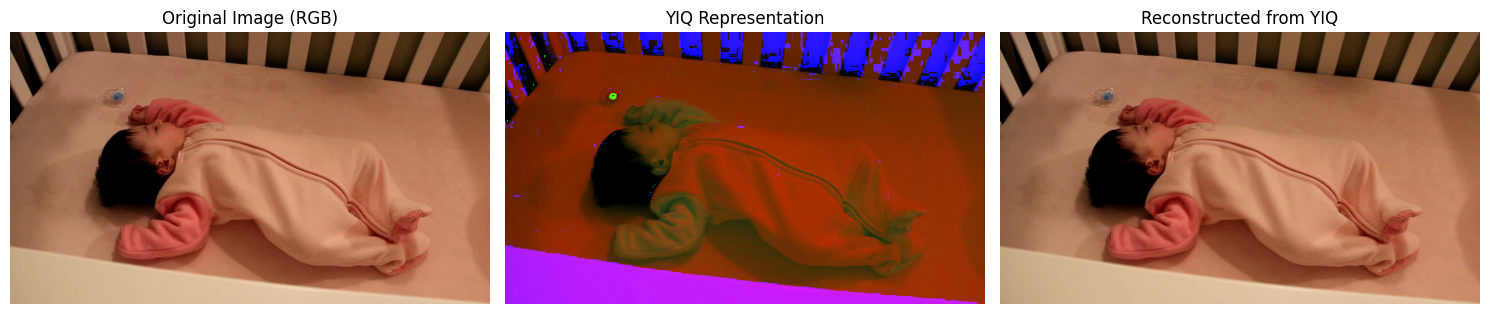

In [7]:
%matplotlib inline
from matplotlib import pyplot as plt

img = cv2.imread("./data/Images/baby_0.jpg",1)

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to YIQ
yiq_img = rgb2yiq(img)

# Convert back to RGB
img_reconstructed = yiq2rgb(yiq_img)
img_reconstructed_rgb = cv2.cvtColor(img_reconstructed, cv2.COLOR_BGR2RGB)

# Display the images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image (RGB)")
axes[0].axis('off')

axes[1].imshow(yiq_img.astype(np.uint8))
axes[1].set_title("YIQ Representation")
axes[1].axis('off')

axes[2].imshow(img_reconstructed_rgb)
axes[2].set_title("Reconstructed from YIQ")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Magnification des couleurs
### 1.3 Construction d'une pyramide de gaussiennes.


Pour magnifier les couleurs, il faut construire une pyramide de gaussiennes de $l$ niveaux pour chaque image de la vidéo d'entrée. Pour cela,  il faudra prendre la version YIQ de chaque image originale et la sous-échantillonner d'un facteur 2 pour chaque nouveau niveau de la pyramide.

La première étape du sous-échantillonnage consiste donc à appliquer à l'image une convolution 2D avec le noyau gaussien 5x5 suivant :

$$G_{k} = \frac{1}{256}\begin{bmatrix}1 & 4 & 6 & 4 & 1\\4 & 16 & 24 & 16 & 4\\6 & 24 & 36 & 24 & 6\\4 & 16 & 24 & 16 & 4\\1 & 4 & 6 & 4 & 1\end{bmatrix}$$



Une fois la convolution effectuée, il ne faut conserver qu'un pixel sur deux dans les lignes et les colonnes de l'image, ce qui nous donne une image sous-échantillonnée dont la hauteur et la largeur sont divisées par 2 par rapport au niveau précédent de la pyramide. Nous effectuons ce processus $l -1 $ fois.

<center><img src='./Figs/gaussianpyramid.png' width=400></center>
Image source : [here](https://iipimage.sourceforge.io/documentation/images/)

Ecrivez la fonction qui prend en entrée une image (dans le bon espace colorimétrique) et qui renvoie une pyramide de gaussiennes de $l$ niveaux. Pour cela, vous pourrez utiliser les fonctions de la bibliothèque OpenCv et notamment la fonction [`pyrDown`](https://docs.opencv.org/4.7.0/d4/d1f/tutorial_pyramids.html) déjà vue en Lab. 

In [8]:
def build_gaussian_pyramid(img, levels):
    '''
    Builds a Gaussian pyramid for an image
    :param img: Input image
    :param levels: Number of pyramid levels
    :return: List of images representing the Gaussian pyramid
    '''
    pyramid = [img]
    
    # Build the pyramid by repeatedly downsampling
    for i in range(levels - 1):
        # Apply pyrDown to downsample the image by factor of 2
        downsampled = cv2.pyrDown(pyramid[-1])
        pyramid.append(downsampled)
    
    return pyramid

Tester votre fonction sur l'image [baby_0.jpg ](./data/Images/baby_0.jpg) avec une pyramide de 5 niveaux. Vous pourrez par exemple tester la fonction sur l'image originale en RGB puis ensuite sur l'image transformée dans l'espace colorimétrique YIQ.

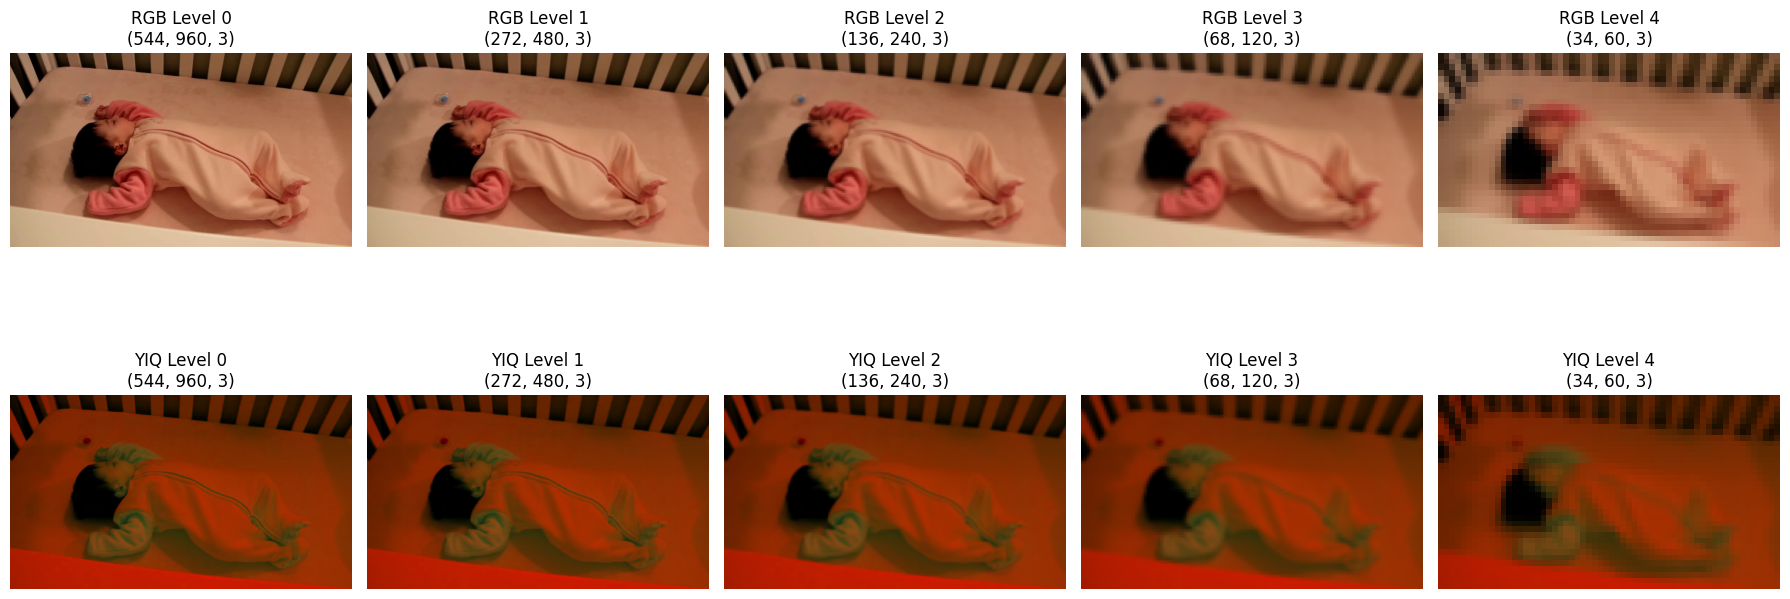

In [9]:
img = cv2.imread("./data/Images/baby_0.jpg",1)

# Build Gaussian pyramid on original RGB image
pyramid_rgb = build_gaussian_pyramid(img, 5)

# Convert to YIQ and build pyramid on YIQ
yiq_img = rgb2yiq(img)
pyramid_yiq = build_gaussian_pyramid(yiq_img, 5)

# Display the Gaussian pyramid
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

# Display RGB pyramid
for i, level in enumerate(pyramid_rgb):
    level_rgb = cv2.cvtColor(level, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(level_rgb)
    axes[0, i].set_title(f"RGB Level {i}\n{level.shape}")
    axes[0, i].axis('off')

# Display YIQ pyramid
for i, level in enumerate(pyramid_yiq):
    # Normalize YIQ for display
    level_display = np.clip(level, 0, 255).astype(np.uint8)
    axes[1, i].imshow(level_display)
    axes[1, i].set_title(f"YIQ Level {i}\n{level.shape}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

Pour les étapes suivantes, vous ne conserverez que le dernier niveau de la pyramide. Plus précisemment, vous allez utiliser la version sur-échantillonnée du dernier niveau de la pyramide. Pour obtenir cette image suréchantillonnée, vous prendrez le dernier niveau de la pyramide, ajouterez un pixel fixé à 0 tous les deux pixels dans les lignes et les colonnes de l'image sous-échantillonnée et appliquerez $ 4 \times G_k$. Vous devez obtenir une image dont la hauteur et la largeur sont multipliées par 2 par rapport à l'image précédemment suréchantillonnée. Ce processus est effectué $l-1$ fois pour obtenir une image sur-échantillonnée de même dimension que l'image originale. Ici aussi, il est recommandé d'utiliser les fonctions de la bibliothèque OpenCv et notamment la fonction [`pyrUp`](https://docs.opencv.org/4.7.0/d4/d1f/tutorial_pyramids.html).

In [10]:
def generate_last_GaussianPyramid(image, level):
    '''
    Upsamples the last level of Gaussian pyramid to original image size
    :param image: Original image
    :param level: Number of pyramid levels
    :return: Upsampled image of original dimensions
    '''
    # Build the Gaussian pyramid
    pyramid = build_gaussian_pyramid(image, level)
    
    # Start with the last (smallest) level
    upsampled = pyramid[-1]
    
    # Upsample back to original size
    for i in range(level - 1):
        # Apply pyrUp to upsample the image by factor of 2
        upsampled = cv2.pyrUp(upsampled)
    
    # Ensure the output has the same dimensions as the input
    # Sometimes there might be slight dimension mismatches
    if upsampled.shape[:2] != image.shape[:2]:
        upsampled = upsampled[:image.shape[0], :image.shape[1]]
    
    return upsampled

Tester votre fonction sur l'image [baby_0.jpg ](./data/Images/baby_0.jpg) avec une pyramide de 5 niveaux. Vous pourrez par exemple tester la fonction sur l'image originale en RGB puis ensuite sur l'image transformée dans l'espace colorimétrique YIQ.

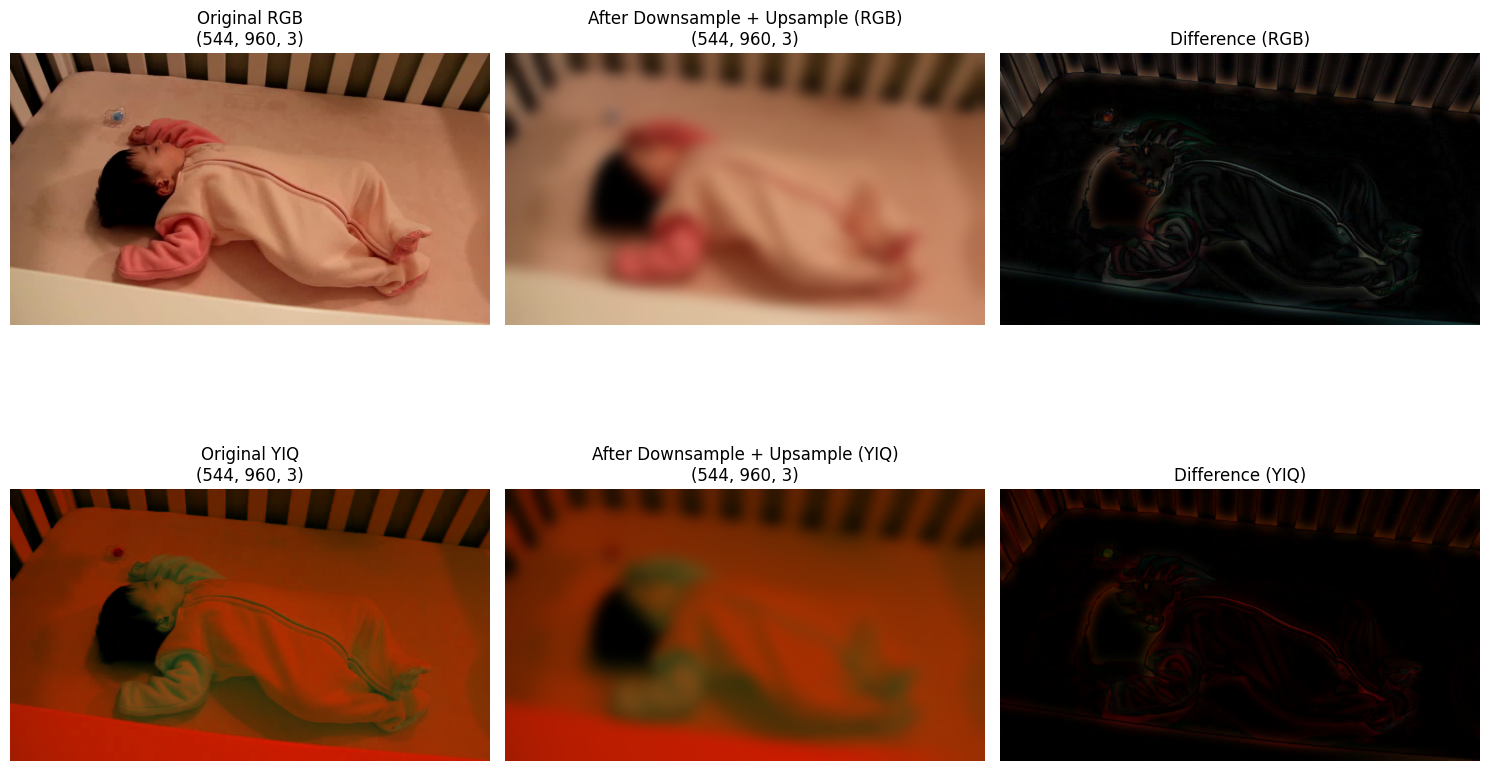

In [11]:
img = cv2.imread("./data/Images/baby_0.jpg",1)

# Test on RGB image
upsampled_rgb = generate_last_GaussianPyramid(img, 5)

# Test on YIQ image
yiq_img = rgb2yiq(img)
upsampled_yiq = generate_last_GaussianPyramid(yiq_img, 5)

# Display comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title(f"Original RGB\n{img.shape}")
axes[0, 0].axis('off')

# Downsampled and upsampled RGB
upsampled_rgb_display = cv2.cvtColor(upsampled_rgb.astype(np.uint8), cv2.COLOR_BGR2RGB)
axes[0, 1].imshow(upsampled_rgb_display)
axes[0, 1].set_title(f"After Downsample + Upsample (RGB)\n{upsampled_rgb.shape}")
axes[0, 1].axis('off')

# Difference
diff_rgb = cv2.absdiff(img, upsampled_rgb.astype(np.uint8))
axes[0, 2].imshow(cv2.cvtColor(diff_rgb, cv2.COLOR_BGR2RGB))
axes[0, 2].set_title("Difference (RGB)")
axes[0, 2].axis('off')

# Original YIQ
axes[1, 0].imshow(np.clip(yiq_img, 0, 255).astype(np.uint8))
axes[1, 0].set_title(f"Original YIQ\n{yiq_img.shape}")
axes[1, 0].axis('off')

# Upsampled YIQ
axes[1, 1].imshow(np.clip(upsampled_yiq, 0, 255).astype(np.uint8))
axes[1, 1].set_title(f"After Downsample + Upsample (YIQ)\n{upsampled_yiq.shape}")
axes[1, 1].axis('off')

# Difference YIQ
diff_yiq = np.abs(yiq_img - upsampled_yiq)
axes[1, 2].imshow(np.clip(diff_yiq, 0, 255).astype(np.uint8))
axes[1, 2].set_title("Difference (YIQ)")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## 1.4 Filtrage Temporel


Cette étape, la plus importante, consiste à filtrer la pyramide de gaussiennes afin de ne conserver que les pixels situés dans la **bande de fréquences** qui nous intéresse $[w_l, w_h]$. Pour cela, nous devons passer du domaine spatial (domaine de l'image) au domaine des fréquences à l'aide d'une transformée de Fourier.

Pour cela, vous allez utiliser le package [`fft`](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html) de la bibliothèque `numpy`.

Si vous n'avez jamais entendu parler de la transformée de Fourier, prenez le temps de lire rapidement ce petit [tutorial](https://homepages.inf.ed.ac.uk/rbf/HIPR2/fourier.htm).


Le code ci-dessous vous montre un exemple d'application de cette bibliothèque sur l'image [baby_0.jpg ](./data/Images/baby_0.jpg)

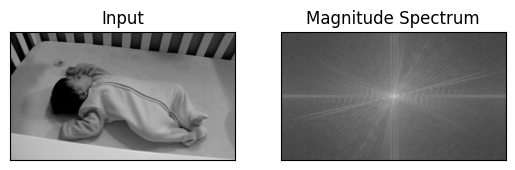

In [12]:
%matplotlib inline
from matplotlib import pyplot as plt

import numpy as np
import cv2


img = cv2.imread("./data/Images/baby_0.jpg",0)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
axis =0

fft = np.fft.fft2(img)

# Shift the zero frequency component (i.e., DC component located at the top-left corner) to the center where it will be more easy to analyze

fftShift = np.fft.fftshift(fft)

# compute the magnitude spectrum of the transform

magnitude = 20 * np.log(np.abs(fftShift))

# Visualize the obtained image
# display the original input image
(fig, ax) = plt.subplots(1, 2, )
ax[0].imshow(img, cmap="gray")
ax[0].set_title("Input")
ax[0].set_xticks([])
ax[0].set_yticks([])
# display the magnitude image
ax[1].imshow(magnitude, cmap="gray")
ax[1].set_title("Magnitude Spectrum")
ax[1].set_xticks([])
ax[1].set_yticks([])
# show our plots
plt.show()




Pour notre problème, il s'agira d'appliquer la transformée de Fourier et de ne conserver que les pixels situés dans la **bande de fréquences** qui nous intéresse $[w_l, w_h]$ ce que l'on pourra faire de la manière suivante.

In [13]:
low=0.8333
high = 1

fft = np.fft.fft(img)
fps = 25

frequencies = np.fft.fftfreq(img.shape[0], d=1.0/fps)
bound_low = (np.abs(frequencies - low)).argmin()
bound_high = (np.abs(frequencies - high)).argmin()

bound_low = (np.abs(frequencies - low)).argmin()
bound_high = (np.abs(frequencies - high)).argmin()
fft[:bound_low] = 0
fft[bound_high:-bound_high] = 0
fft[-bound_low:] = 0



Il faut ensuite appliquer la transformée de Fourier inverse pour obtenir une image filtrée. Le résultat d'une transformée de Fourier inverse est une matrice de nombres complexes, il faudra donc prendre la la partie réelle de chaque nombre de la matrice complexe.

In [14]:
resultifft = np.fft.ifft(fft, axis=0).real

A partir des exemples précédents, écrire une fonction `idealTemporalBandpassFilter` qui prend en argument une image, un paramètre `fps`(frame per second), la banque de fréquence voulue (paramètres `low` et `high`) et un argument `axis` qui est fixé par défaut à 0 et qui renvoie la transformée inverse filtrée.

In [15]:
def idealTemporalBandpassFilter(images,
                                fps,
                                freq_range,
                                axis=0):
    '''
    Applies an ideal temporal bandpass filter to a sequence of images
    :param images: Sequence of images (3D array where first dimension is time)
    :param fps: Frame rate (frames per second)
    :param freq_range: Tuple (low, high) specifying the frequency band to keep
    :param axis: Axis along which to apply FFT (default 0 for temporal axis)
    :return: Filtered image sequence (real part of inverse FFT)
    '''
    low, high = freq_range
    
    # Get the number of frames
    num_frames = images.shape[axis]
    
    # Apply FFT along the temporal axis
    fft = np.fft.fft(images, axis=axis)
    
    # Compute frequency values
    frequencies = np.fft.fftfreq(num_frames, d=1.0/fps)
    
    # Find the indices of the frequency bounds
    bound_low = (np.abs(frequencies - low)).argmin()
    bound_high = (np.abs(frequencies - high)).argmin()
    
    # Create a copy of the FFT for filtering
    fft_filtered = fft.copy()
    
    # Zero out frequencies outside the desired band
    # Keep only the positive frequencies in [low, high] and their negative counterparts
    if axis == 0:
        fft_filtered[:bound_low] = 0
        fft_filtered[bound_high:-bound_high] = 0
        fft_filtered[-bound_low:] = 0
    else:
        # Handle other axes if needed
        pass
    
    # Apply inverse FFT and take the real part
    filtered_images = np.fft.ifft(fft_filtered, axis=axis).real
    
    return filtered_images

## 1.5 Magnification de l' image et reconstruction.

Pour amplifier les couleurs obtenues avec la pyramide filtrée $F_p$, il est nécessaire d'introduire une valeur $\alpha$ qui va agir comme une **facteur d'amplification**. Pour éviter la création d'artefacts dans l'image de sortie, nous introduisons une autre valeur $A$ qui agira comme un facteur d'atténuation pour les composantes de chrominance de l'image. Nous obtenons notre pyramide filtrée magnifiée $M_{F_P}$ avec une atténuation de la chrominance avec la formule suivante :

$$M_{F_{p}} = \begin{cases}\alpha F_{p}\ \text{if Y component}\\ \alpha A F_{p}\ \text{if I or Q component}\end{cases}$$

On peut finalement reconstruire l'image en ajoutant $M_{F_P}$ à la version YIQ de l'image originale et en convertissant l'image résultante en RGB en pensant bien à limiter les valeurs dans l'intervalle $[0,255]$ pour chaque composante. Ce processus devra être répété pour chaque frame de la vidéo.



Ecrire une fonction `filterGaussianPyramids` qui, pour une frame donnée, prend en entrée la pyramide de gaussiennes, la filtre, applique les opérations d'amplification et d'attenuation. Cette fonction prendra aussi en arguments le `fps`, la bande de fréquences et les paramètres `alpha` et `attenuation`. 


In [16]:
def filterGaussianPyramids(pyramids,
                           fps,
                           freq_range,
                           alpha,
                           attenuation):
    '''
    Filters Gaussian pyramid levels, applies amplification and attenuation
    :param pyramids: List of Gaussian pyramid levels
    :param fps: Frame rate
    :param freq_range: Tuple (low, high) for frequency filtering
    :param alpha: Amplification factor
    :param attenuation: Attenuation factor for chrominance components
    :return: Filtered and magnified pyramid
    '''
    # Apply temporal filtering to each pyramid level
    filtered_pyramid = idealTemporalBandpassFilter(np.array(pyramids), fps, freq_range, axis=0)
    
    # Apply magnification with attenuation
    magnified_pyramid = filtered_pyramid.copy()
    
    # For each level in the pyramid
    for level_idx in range(filtered_pyramid.shape[0]):
        # Y component (index 0) gets full alpha
        magnified_pyramid[level_idx, :, :, 0] *= alpha
        
        # I and Q components (indices 1, 2) get attenuated alpha
        magnified_pyramid[level_idx, :, :, 1] *= (alpha * attenuation)
        magnified_pyramid[level_idx, :, :, 2] *= (alpha * attenuation)
    
    return magnified_pyramid

Ecrire une fonction qui reconstruit l'image magnifiée en ajoutant $M_{F_P}$ à la version YIQ de l'image originale et en convertissant l'image résultante en RGB en pensant bien à limiter les valeurs dans l'intervalle $[0,255]$ pour chaque composante. Elle prendra en argument l'image originale et la pyramide de gaussienne filtrée.

In [17]:
def reconstructGaussianImage(image, pyramid):
    '''
    Reconstructs a magnified image from filtered Gaussian pyramid
    :param image: Original image in YIQ format
    :param pyramid: Filtered and magnified Gaussian pyramid
    :return: Reconstructed image in BGR format
    '''
    # Use only the last (lowest resolution) level of the pyramid
    # and upsample it back to original size
    upsampled = pyramid[-1].copy()
    
    # Upsample back to original resolution
    num_levels = len(pyramid)
    for i in range(num_levels - 1):
        upsampled = cv2.pyrUp(upsampled)
    
    # Ensure correct dimensions
    if upsampled.shape[:2] != image.shape[:2]:
        upsampled = upsampled[:image.shape[0], :image.shape[1]]
    
    # Convert original image to YIQ if not already
    if len(image.shape) == 3 and image.shape[2] == 3:
        # Check if it's BGR or already YIQ
        img_yiq = rgb2yiq(image.astype(np.uint8)) if image.max() > 1 else image
    else:
        img_yiq = image
    
    # Add magnified signal to original image
    magnified_yiq = img_yiq + upsampled
    
    # Clip values to valid range
    magnified_yiq = np.clip(magnified_yiq, 0, 255)
    
    # Convert back to BGR
    reconstructed = yiq2rgb(magnified_yiq)
    
    return reconstructed

Tester vos fonctions sur l'image `baby_0.jpg` avec une pyramide de 4 niveaux, 

Pyramid levels: 4
Pyramid level shapes: [(544, 960, 3), (272, 480, 3), (136, 240, 3), (68, 120, 3)]
Lowest level sequence shape: (10, 68, 120, 3)
Filtered lowest level shape: (10, 68, 120, 3)


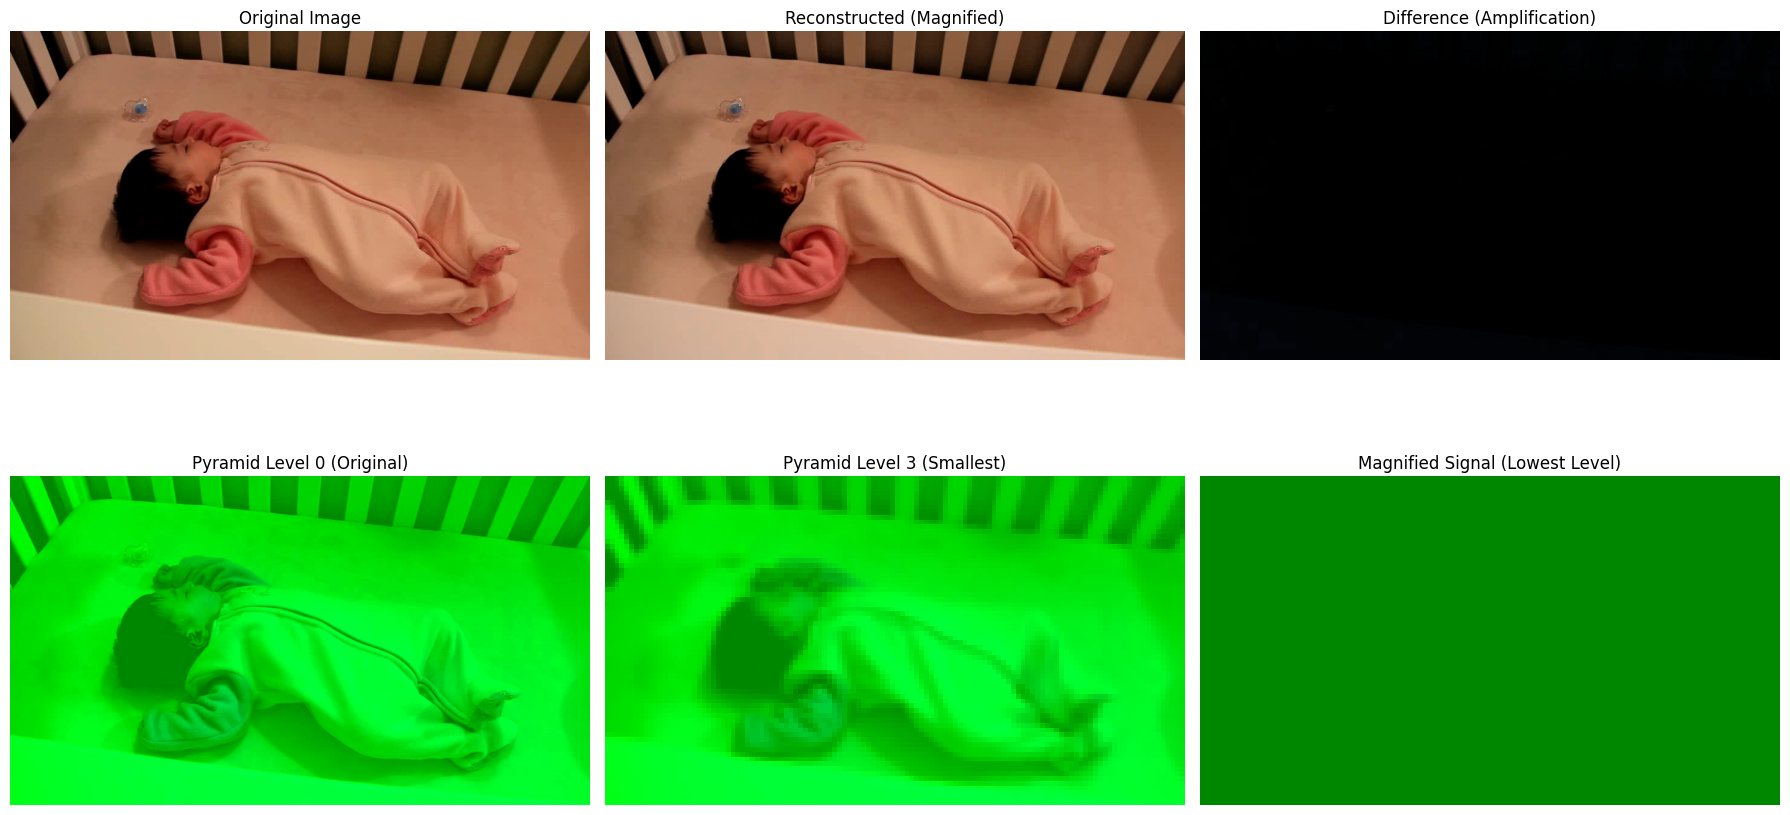

In [18]:
img = cv2.imread("./data/Images/baby_0.jpg", 1)

# Parameters for magnification
levels = 4
fps = 25
freq_range = (0.5, 2.0)
alpha = 15
attenuation = 0.1

# Convert to YIQ
yiq_img = rgb2yiq(img)

# Build Gaussian pyramid
pyramid = build_gaussian_pyramid(yiq_img, levels)
print(f"Pyramid levels: {len(pyramid)}")
print(f"Pyramid level shapes: {[p.shape for p in pyramid]}")

# Apply temporal filtering directly to the lowest resolution level
# and magnify it
num_frames = 10

# Create a sequence of the lowest level image
lowest_level = pyramid[-1]
lowest_level_sequence = np.array([lowest_level for _ in range(num_frames)])
print(f"Lowest level sequence shape: {lowest_level_sequence.shape}")

# Apply temporal filtering
filtered_lowest = idealTemporalBandpassFilter(lowest_level_sequence, fps, freq_range, axis=0)
print(f"Filtered lowest level shape: {filtered_lowest.shape}")

# Apply magnification (frame in the middle)
magnified_lowest = filtered_lowest[5].copy()
magnified_lowest[:, :, 0] *= alpha  # Y component
magnified_lowest[:, :, 1] *= (alpha * attenuation)  # I component
magnified_lowest[:, :, 2] *= (alpha * attenuation)  # Q component

# Upsample back to original size
upsampled = magnified_lowest.copy()
for i in range(levels - 1):
    upsampled = cv2.pyrUp(upsampled)

# Ensure correct dimensions
if upsampled.shape[:2] != yiq_img.shape[:2]:
    upsampled = upsampled[:yiq_img.shape[0], :yiq_img.shape[1]]

# Add magnified signal to original image
magnified_yiq = yiq_img + upsampled
magnified_yiq = np.clip(magnified_yiq, 0, 255)

# Convert back to BGR
reconstructed = yiq2rgb(magnified_yiq)

# Display results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Original
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

# Reconstructed
reconstructed_rgb = cv2.cvtColor(reconstructed, cv2.COLOR_BGR2RGB)
axes[0, 1].imshow(reconstructed_rgb)
axes[0, 1].set_title("Reconstructed (Magnified)")
axes[0, 1].axis('off')

# Difference
diff = cv2.absdiff(img, reconstructed)
diff_rgb = cv2.cvtColor(diff, cv2.COLOR_BGR2RGB)
axes[0, 2].imshow(diff_rgb)
axes[0, 2].set_title("Difference (Amplification)")
axes[0, 2].axis('off')

# Show pyramid levels
axes[1, 0].imshow(cv2.cvtColor(np.clip(pyramid[0], 0, 255).astype(np.uint8), cv2.COLOR_YCrCb2BGR))
axes[1, 0].set_title("Pyramid Level 0 (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(np.clip(pyramid[-1], 0, 255).astype(np.uint8), cv2.COLOR_YCrCb2BGR))
axes[1, 1].set_title(f"Pyramid Level {levels-1} (Smallest)")
axes[1, 1].axis('off')

# Show the magnified signal
magnified_signal_clipped = np.clip(magnified_lowest, 0, 255).astype(np.uint8)
axes[1, 2].imshow(cv2.cvtColor(magnified_signal_clipped, cv2.COLOR_YCrCb2BGR))
axes[1, 2].set_title("Magnified Signal (Lowest Level)")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### 1.6 Application à la vidéo


Ecrire le code permettant d'appliquer cela à une vidéo et qui renverra donc la vidéo magnifiée.

In [19]:
def gaussian_video(video_tensor, levels, fps, freq_range, alpha, attenuation):
    '''
    Applies color magnification to a video sequence using Gaussian pyramid filtering
    :param video_tensor: Video sequence (N frames)
    :param levels: Specifies the Gaussian pyramid levels
    :param fps: Frame rate
    :param freq_range: Tuple (low, high) for frequency band
    :param alpha: Amplification factor
    :param attenuation: Attenuation factor for chrominance
    :return: Magnified video sequence
    '''
    print('Processing video with Gaussian pyramid magnification...')
    
    # Convert video to YIQ
    print('Converting video to YIQ...')
    video_yiq = []
    for frame in video_tensor:
        yiq_frame = rgb2yiq(frame)
        video_yiq.append(yiq_frame)
    video_yiq = np.array(video_yiq)
    
    # Get video dimensions
    num_frames = video_yiq.shape[0]
    height, width = video_yiq.shape[1:3]
    
    # Build Gaussian pyramids for all frames
    print('Building Gaussian pyramids for all frames...')
    pyramids = []
    for i, frame in enumerate(video_yiq):
        if i % 50 == 0:
            print(f"  Frame {i}/{num_frames}")
        pyramid = build_gaussian_pyramid(frame, levels)
        pyramids.append(pyramid)
    
    # Process the lowest resolution level temporally
    print('Extracting and filtering lowest pyramid level...')
    lowest_levels = np.array([pyramids[i][-1] for i in range(num_frames)])
    
    # Apply temporal filtering
    filtered_lowest = idealTemporalBandpassFilter(lowest_levels, fps, freq_range, axis=0)
    
    # Apply magnification and reconstruct
    print('Magnifying and reconstructing frames...')
    magnified_video = []
    
    for frame_idx in range(num_frames):
        if frame_idx % 50 == 0:
            print(f"  Frame {frame_idx}/{num_frames}")
        
        # Get magnified lowest level
        magnified_lowest = filtered_lowest[frame_idx].copy()
        magnified_lowest[:, :, 0] *= alpha  # Y component
        magnified_lowest[:, :, 1] *= (alpha * attenuation)  # I component
        magnified_lowest[:, :, 2] *= (alpha * attenuation)  # Q component
        
        # Upsample back to original size
        upsampled = magnified_lowest.copy()
        for i in range(levels - 1):
            upsampled = cv2.pyrUp(upsampled)
        
        # Ensure correct dimensions
        if upsampled.shape[:2] != (height, width):
            upsampled = upsampled[:height, :width]
        
        # Add magnified signal to original image
        original_yiq = video_yiq[frame_idx]
        magnified_yiq = original_yiq + upsampled
        magnified_yiq = np.clip(magnified_yiq, 0, 255)
        
        # Convert back to BGR
        reconstructed = yiq2rgb(magnified_yiq)
        magnified_video.append(reconstructed)
    
    magnified_video = np.array(magnified_video)
    print(f'Video magnification completed. Output shape: {magnified_video.shape}')
    
    return magnified_video

In [20]:
low = 0.4
high = 3
alpha = 15
chromAttenuation = 0.1
levels = 4

print("Loading video...")
video_tensor, fps, width, height = load_video("./data/baby.mp4")
print(f"Video loaded: {video_tensor.shape}, FPS: {fps}")

# Apply color magnification
print("\nApplying color magnification...")
magnified_video = gaussian_video(video_tensor, levels, fps, (low, high), alpha, chromAttenuation)

# Save the magnified video
print("\nSaving magnified video...")
save_video(magnified_video, fps, "./data/baby_magnified_color")
print("Done! Video saved as ./data/baby_magnified_colorOut.avi")

Loading video...
Load video
Video loaded: (301, 544, 960, 3), FPS: 30.0

Applying color magnification...
Processing video with Gaussian pyramid magnification...
Converting video to YIQ...
Building Gaussian pyramids for all frames...
  Frame 0/301
  Frame 50/301
  Frame 100/301
  Frame 150/301
  Frame 200/301
  Frame 250/301
  Frame 300/301
Extracting and filtering lowest pyramid level...
Magnifying and reconstructing frames...
  Frame 0/301
  Frame 50/301
  Frame 100/301
  Frame 150/301
  Frame 200/301
  Frame 250/301
  Frame 300/301
Video magnification completed. Output shape: (301, 544, 960, 3)

Saving magnified video...
Save video
Video saved successfully as ./data/baby_magnified_colorOut.avi
Done! Video saved as ./data/baby_magnified_colorOut.avi



## Magnification des mouvements
### 1.6 Pyramide de laplaciens

Pour la magnification des mouvements, il faut se concentrer sur les bords des objets dans la vidéo. Pour cela, vous allez utiliser la différence entre deux niveaux adjacents de la pyramide gaussienne, c'est-à-dire une pyramide de Laplacien comme illustré sur la figure ci-dessous

<center><img src='./Figs/laplacian_pyramid.png' width=500></center>



Ecrire la fonction `create_laplacian_pyramid` qui prend en agurment une image et le niveau voulu $l$ de la pyramide et qui renvoie une pyramide de laplacien de $l$ niveaux.

In [21]:
def create_laplacian_pyramid(image, levels):
    '''
    Builds a Laplace pyramid for an image, i.e. video frame
    :param image: Image,  i.e. single video frame
    :param levels: Specifies the Laplace pyramid levels
    :return: Returns a pyramid of nr. levels images
    '''
    # First build the Gaussian pyramid
    gaussian_pyramid = build_gaussian_pyramid(image, levels)
    
    # Initialize Laplacian pyramid
    laplacian_pyramid = []
    
    # For each level except the last one, compute Laplacian as difference
    for i in range(levels - 1):
        # Upsample the next level
        upsampled = cv2.pyrUp(gaussian_pyramid[i + 1])
        
        # Match dimensions if necessary
        if upsampled.shape[:2] != gaussian_pyramid[i].shape[:2]:
            upsampled = upsampled[:gaussian_pyramid[i].shape[0], :gaussian_pyramid[i].shape[1]]
        
        # Compute Laplacian: current level - upsampled next level
        laplacian = gaussian_pyramid[i] - upsampled
        laplacian_pyramid.append(laplacian)
    
    # The last level of Laplacian pyramid is the last Gaussian level
    laplacian_pyramid.append(gaussian_pyramid[-1])
    
    return laplacian_pyramid

Ecrire une fonction qui permet de créer la pyramide des laplaciens pour l'ensemble d'une vidéo.

In [22]:
def laplacian_video_pyramid(video_stack, levels):
    '''
    Creates a Laplacian pyramid for the whole video sequence
    :param video_stack: Video sequence
    :param levels: Specifies the Laplace pyramid levels
    :return: A two-dimensional array where the first index is used for the pyramid levels
    and the second for each video frame
    '''
    print('Build laplace pyramid')
    
    num_frames = video_stack.shape[0]
    
    # Initialize list to store pyramids for each level across all frames
    laplacian_video_pyramid_list = [[] for _ in range(levels)]
    
    # For each frame in the video
    for frame_idx in range(num_frames):
        if frame_idx % 50 == 0:
            print(f"  Processing frame {frame_idx}/{num_frames}")
        
        # Create Laplacian pyramid for this frame
        laplacian_pyramid = create_laplacian_pyramid(video_stack[frame_idx], levels)
        
        # Append each level to the corresponding list
        for level_idx in range(levels):
            laplacian_video_pyramid_list[level_idx].append(laplacian_pyramid[level_idx])
    
    # Convert each level list to numpy array
    laplacian_video_pyramid_array = []
    for level_idx in range(levels):
        level_array = np.array(laplacian_video_pyramid_list[level_idx])
        laplacian_video_pyramid_array.append(level_array)
    
    print(f'Laplacian pyramid built with {levels} levels and {num_frames} frames')
    
    return laplacian_video_pyramid_array

### 1.7 Filtre de Butterworth

Pour l'étape de filtrage de la magnification des mouvements, il faut un filtre qui tolère les fréquences en dehors de la plage donnée, car les changements de mouvements ne sont pas aussi uniformes que les changements de couleurs. Nous utiliserons donc un filtre de Butterworth dont un descriptif est donné [ici](https://fr.wikipedia.org/wiki/Filtre_de_Butterworth).

Dans le papier original, les auteurs proposent d'utiliser un filtre passe-bande de Butterworth du premier ordre, comme dans l'exemple suivant.

<center><img src='./Figs/butterworth.png' width=500></center>


Filtre de Butterworth avec $w_l = 2 $ et $w_h = 4$.





Pour filtrer les images, il faut d'abord calculer les coefficients
 $b_i$ et $a_i$ du filtre de Butterworth étant donné la bande de fréquence $[w_l, w_h]$ et le frame rate $fps$ de la video comme fréquence temporelle.


Pour ce filtrage, vous pourrez utiliser la fonction [`butter`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html) de `scipy`.
 
 
Vous trouverez ci-dessous la fonction  `butter_bandpass` qui calcule le filtre de Butterworth d'ordre 1 étant donné la bande de fréquence et le frame rate.
 
 
 

In [23]:
from scipy.signal import butter, lfilter

def butter_bandpass(lowcut, highcut, fps, order=1):
    '''
    Calculates the Butterworth bandpass filter
    :param lowcut: low frequency cutoff
    :param highcut: high frequency cutoff
    :param fs: video frame rate
    :param order: filter order - per default = 1
    :return: Numerator (b) and denominator (a) polynomials of the IIR filter.
    '''

    low = lowcut / fps
    high = highcut / fps
    b, a = butter(order, [low, high], btype='band')
    return b, a

### 1.8 Application du filtre de Butterworth au Laplacien.

Il s'agit maintenant d'appliquer le filtre en suivant l'équation ci-dessous.

$$y[n] = \frac{1}{a_0}(b_{0}x[n] + b_{1}x[n - 1] - a_{1}y[n - 1])$$
 
Avec  $y[n]$ la nième image de la pyramide laplacienne filtrée et $x[n]$ la nième pyramide de Laplace (correspondant à la nième frame)

$y[0]$  et $x[0]$ sont les pyramides de Laplace pour la première frame de la vidéo.


Ecrire la fonction `apply_filter_butter` qui prend en entrée une séquence d'images et qui applique l'équation précédente, donc le filtre de Butterworth à tous les niveaux d'une pyramide de Laplace d'une séquence d'images.


In [24]:
def apply_filter_butter_to_lapalcian(laplace_video_list, levels, low, high, fps):
    '''
    Applies the Butterworth filter on video sequence
    :param laplace_video_list: Laplace video pyramid
    :param levels: Pyramid levels
    :param low: Temporal low frequency cutoff
    :param high: Temporal high frequency cutoff
    :param fps: Frame rate
    :return: Filtered Laplace pyramid
    '''

    print('Apply Butterworth filter')
    
    # Get Butterworth filter coefficients
    b, a = butter_bandpass(low, high, fps, order=1)
    
    # List to store filtered pyramids
    filtered_laplace_video = []
    
    # Apply filter to each pyramid level
    for level_idx in range(levels):
        print(f"  Filtering level {level_idx}/{levels-1}")
        
        # Get the image sequence for this pyramid level
        level_sequence = laplace_video_list[level_idx]  # Shape: (num_frames, height, width, 3)
        num_frames, height, width, channels = level_sequence.shape
        
        # Initialize filtered level
        filtered_level = np.zeros_like(level_sequence)
        
        # Apply Butterworth filter to each pixel channel
        # Using lfilter for temporal filtering
        for h in range(height):
            for w in range(width):
                for c in range(channels):
                    # Extract temporal signal for this pixel
                    temporal_signal = level_sequence[:, h, w, c]
                    
                    # Apply Butterworth filter
                    filtered_signal = lfilter(b, a, temporal_signal)
                    
                    # Store filtered signal
                    filtered_level[:, h, w, c] = filtered_signal
        
        filtered_laplace_video.append(filtered_level)
    
    return filtered_laplace_video

### 1.8 Magnification & Reconstruction

Dans le cas de la magnification de mouvements, tous les niveaux de la pyramide de Laplacien sont utilisés et donc l'étape de magnification et de reconstruction des mouvements est un peu plus compliquée. Tout d'abord, nous devons adapter dynamiquement le facteur d'amplification pour chaque niveau de la pyramide. Pour ce faire, nous introduisons la longueur d'onde spatiale $\lambda$ qui représente un niveau donnée de la pyramide de Laplace filtrée 

$$\lambda = \sqrt{h^{2} + w^{2}}$$

Avec $h$ et $w$ qui sont respectivement la hauteur et la largeur du niveau considéré. 

$\lambda$ et le facteur d'amplification $\alpha$ sont liés par l'équation suivante : 

$$(1 + \alpha)\delta (t) < \frac{\lambda}{8}$$

Avec $\delta (t)$ le facteur de déplacement (se reporter à l'article pour plus de détails).

Nous pouvons maintenant introduire la longueur d'onde spatiale de coupure $\lambda_{c}$

$$(1 + \alpha)\delta(t) = \frac{\lambda_{c}}{8} \implies \delta(t) = \frac{\frac{\lambda_{c}}{8}}{1 + \alpha}$$

Le nouveau facteur d'amplication $\alpha_{\textrm{new}}$ pour un niveau donnée de la pyramide $F_p$ peut alors être obtenu par 

$$\alpha_{\textrm{new}} = \frac{\frac{\lambda}{8}}{\delta(t)} - 1$$

Le facteur d'amplication est alors pour un niveau $l$ de $F_p$

$$\alpha_{l} = min(\alpha, \alpha_{\textrm{new}})$$

De la même manière que pour la magnification de la pyramide de Gaussiennes, nous obtenons notre niveau de pyramide filtrée magnifiée avec 

$$M_{F_{p}}[l] = \begin{cases}\alpha_{l} F_{p}[l]\ \text{if Y component}\\ \alpha_{l} A F_{p}[l]\ \text{if I or Q component}\end{cases}$$


Nous répétons le processus précédent pour tous les niveaux (sauf le premier et le dernier) de $F_p$.

Enfin, nous reconstruisons notre image en suréchantillonnant tous les niveaux de $M_{F_{p}}$ aux dimensions de l'image originale, en l'ajoutant à la version YIQ de l'image originale, en convertissant l'image résultante en RVB et en limitant les valeurs de l'image RVB résultante à $[0,255]$. Ce processus est répété pour chaque frame de la vidéo.

Compléter la fonction ci-dessous qui permet de mettre en oeuvre ce processus.

In [25]:
def apply_butter(laplace_video_list, levels, alpha, cutoff, low, high, fps, width, height, linearAttenuation):
    '''
    Applies the Butterworth filter on video sequence, magnifies the filtered video sequence
    and cuts off spatial frequencies
    :param laplace_video_list: Laplace video pyramid
    :param levels: Pyramid levels
    :param alpha: Magnification factor
    :param cutoff: Spatial frequencies cutoff factor
    :param low: Temporal low frequency cutoff
    :param high: Temporal high frequency cutoff
    :param fps: Video frame rate
    :param width: Video frame width
    :param height: Video frame height
    :param linearAttenuation: Boolean if linear attenuation should be applied
    :return: Filtered and magnified video list
    '''

    print('Apply Butterworth filter and magnification')
    filtered_video_list = []
    b, a = butter_bandpass(low, high, fps, order=1)

    # Spatial wavelength lambda (spatial resolution at each pyramid level)
    # lambda = sqrt(h^2 + w^2) for the image dimensions
    lambda_val = np.sqrt(height**2 + width**2)
    
    # Delta displacement factor based on cutoff spatial frequency
    # delta = (lambda_c / 8) / (1 + alpha)
    delta = (cutoff / 8.0) / (1.0 + alpha)

    for i in range(levels):  # pyramid levels
        print(f"  Level {i}/{levels-1}")
        
        # Get the level sequence
        level_sequence = laplace_video_list[i]
        num_frames, level_h, level_w, channels = level_sequence.shape
        
        # Calculate wavelength for this pyramid level
        # Each level is downsampled by factor 2
        lambda_level = np.sqrt((level_h**2 + level_w**2))
        
        # Calculate new amplification factor for this level
        # alpha_new = (lambda / 8) / delta - 1
        alpha_new = (lambda_level / 8.0) / delta - 1.0
        
        # Use minimum of alpha and alpha_new to avoid artifacts
        current_alpha = min(alpha, alpha_new)
        
        # Apply Butterworth filter to this level
        filtered_level = np.zeros_like(level_sequence)
        for h in range(level_h):
            for w in range(level_w):
                for c in range(channels):
                    temporal_signal = level_sequence[:, h, w, c]
                    filtered_signal = lfilter(b, a, temporal_signal)
                    filtered_level[:, h, w, c] = filtered_signal
        
        # Apply magnification with attenuation for chrominance
        magnified_level = filtered_level.copy()
        magnified_level[:, :, :, 0] *= current_alpha  # Y component: full alpha
        magnified_level[:, :, :, 1] *= (current_alpha * linearAttenuation)  # I component: attenuated
        magnified_level[:, :, :, 2] *= (current_alpha * linearAttenuation)  # Q component: attenuated
        
        filtered_video_list.append(magnified_level)
    
    return filtered_video_list

Ecrire une fonction qui permet de reconstruire une séquence vidéo à partir de la pyramide de Laplaciens filtrée

In [26]:
def reconstruct(filtered_video, levels):
    '''
    Reconstructs a video sequence from the filtered Laplace video pyramid
    :param filtered_video: 2 dimensional video sequence - 1st. index pyramid levels, 2nd. - video frames
    :param levels: pyramid levels
    :return: video sequence reconstructed in YIQ format
    '''
    print('Reconstruct video')
    
    # Get dimensions
    num_frames = filtered_video[0].shape[0]
    
    # Initialize output video
    reconstructed_video = []
    
    # Reconstruct each frame
    for frame_idx in range(num_frames):
        if frame_idx % 50 == 0:
            print(f"  Reconstructing frame {frame_idx}/{num_frames}")
        
        # Start with the smallest (coarsest) pyramid level
        reconstructed = filtered_video[-1][frame_idx].copy()
        
        # Upsample and add each coarser level (bottom-up reconstruction)
        for level_idx in range(levels - 2, -1, -1):
            # Upsample the current reconstruction
            reconstructed = cv2.pyrUp(reconstructed)
            
            # Match dimensions
            original_shape = filtered_video[level_idx][frame_idx].shape
            if reconstructed.shape[:2] != original_shape[:2]:
                reconstructed = reconstructed[:original_shape[0], :original_shape[1]]
            
            # Add the current level
            reconstructed += filtered_video[level_idx][frame_idx]
        
        reconstructed_video.append(reconstructed)
    
    reconstructed_video = np.array(reconstructed_video)
    print(f'Video reconstructed: {reconstructed_video.shape}')
    
    return reconstructed_video

Ecrire une fontion qui permet de mettre en place l'amplification de mouvement sur une vidéo complète et sauvegarder la vidéo amplifiée.

In [27]:
def motionmagnification(vidFile, alpha, cutoff, low, high, chromAttenuation, name):
    '''
    Performs motion magnification on the video by applying Butterworth bandpass filter and saves the output video
    :param vidFile: Video file
    :param alpha: Magnification factor
    :param cutoff: Spatial frequencies cutoff factor
    :param low: Temporal low frequency cutoff
    :param high: Temporal high frequency cutoff
    :param chromAttenuation: chrominance attenuation 
    :param name: Output video name
    '''
    
    # Load video
    print("Loading video...")
    video_tensor, fps, width, height = load_video(vidFile)
    print(f"Video loaded: {video_tensor.shape}, FPS: {fps}, Resolution: {width}x{height}")
    
    levels = 4  # Number of pyramid levels
    
    # Convert video to YIQ
    print("Converting video to YIQ...")
    video_yiq = []
    for frame in video_tensor:
        yiq_frame = rgb2yiq(frame)
        video_yiq.append(yiq_frame)
    video_yiq = np.array(video_yiq)
    
    # Build Laplacian pyramid for the entire video
    print("Building Laplacian pyramids...")
    laplacian_pyramid = laplacian_video_pyramid(video_yiq, levels)
    
    # Apply Butterworth filter and magnification
    print("Applying Butterworth filter and magnification...")
    filtered_video = apply_butter(laplacian_pyramid, levels, alpha, cutoff, low, high, fps, width, height, chromAttenuation)
    
    # Reconstruct video from Laplacian pyramid
    print("Reconstructing video...")
    reconstructed_yiq = reconstruct(filtered_video, levels)
    
    # Add reconstructed magnified signal to original video
    print("Adding magnified signal to original video...")
    num_frames = video_yiq.shape[0]
    magnified_yiq = video_yiq + reconstructed_yiq
    magnified_yiq = np.clip(magnified_yiq, 0, 255)
    
    # Convert back to BGR
    print("Converting back to BGR...")
    magnified_video = []
    for frame in magnified_yiq:
        bgr_frame = yiq2rgb(frame)
        magnified_video.append(bgr_frame)
    magnified_video = np.array(magnified_video)
    
    # Save the magnified video
    print("Saving magnified video...")
    save_video(magnified_video, fps, name)
    print(f"Motion magnification complete! Video saved as {name}Out.avi")

Tester sur les vidéos du répertoire [data](./data). Vous sauvegarderez les vidéos résultats. Ci-dessous un ensemble de valeurs pour les paramètres pour la vidéo baby mais vous pouvez bien evidemment tester différents paramètres.

In [28]:
# Quelques paramètres à utiliser

# pour la video baby

low = 0.4
high = 3
alpha = 15
chromAttenuation = 0.1
cutoff =  16



In [29]:
# Test motion magnification on baby.mp4
motionmagnification('./data/baby.mp4', alpha, cutoff, low, high, chromAttenuation, './data/baby_magnified.mp4')

Loading video...
Load video
Video loaded: (301, 544, 960, 3), FPS: 30.0, Resolution: 960x544
Converting video to YIQ...
Building Laplacian pyramids...
Build laplace pyramid
  Processing frame 0/301
  Processing frame 50/301
  Processing frame 100/301
  Processing frame 150/301
  Processing frame 200/301
  Processing frame 250/301
  Processing frame 300/301
Laplacian pyramid built with 4 levels and 301 frames
Applying Butterworth filter and magnification...
Apply Butterworth filter and magnification
  Level 0/3
  Level 1/3
  Level 2/3
  Level 3/3
Reconstructing video...
Reconstruct video
  Reconstructing frame 0/301
  Reconstructing frame 50/301
  Reconstructing frame 100/301
  Reconstructing frame 150/301
  Reconstructing frame 200/301
  Reconstructing frame 250/301
  Reconstructing frame 300/301
Video reconstructed: (301, 544, 960, 3)
Adding magnified signal to original video...
Converting back to BGR...
Saving magnified video...
Save video
Video saved successfully as ./data/baby_magn

# Partie 2 : Générateur d'images Low Poly


L'objectif de cette partie est de mettre en place plusieurs approches simples permettant, à partir d'une image source de générer une image artistique dite Low Poly.
Ces images ont comme particularité  :

 + Les objets illustrés sont très abstraits et schématiques. Ils ne respectent pas vraiment la réalité.
 + Les objets sont illustrés à l'aide de formes basiques, tels que des triangles et des polygones simples.
 + Une palette de couleur simple est utilisé et il n'y pas beaucoup de contenu fréquentielle ou des textures complexes.

Il s'agit ici. de développer des fonctions permettant de transformer une image en une version Low-Poly comme sur l'exemple ci-dessous


<center><img src='./Figs/oscar.jpg' width=200></center>


<center><img src='./Figs/oscarlowpoly.png' width=200></center>

## 2.1 : Approche à l'aide de points d'intérêts

Une première approche consiste à faire en place la chaîne de traitements suivantes :

 1. Déterminer des points  (d'interêts ) dans l'image
 2. Générer une triangulation de type Delaunay
 3. Remplir les triangles à l'aide des couleurs de l'image originale.

Il s'agit donc de mettre en place cette première statégie.


Pour l'extraction des points dans l'image, vous comparerez trois stratégies :
 + La sélection de points de manière aléatoire
 + La sélection de points sur les contours
 + la sélection de points d'intérêts (Harris, sift et cie)

### 2.1.1 Extraction de points d'intérêts de manière aléatoire

Ecrire une fonction qui prend en entrée une image et qui selectionne de manière aléatoire un ensemble de $n$ points dans une image et qui renvoie cet ensemble de points.


In [31]:
def select_at_random (img, n):
    """
    Selects n random points in the image.
    
    Args:
        img: Input image
        n: Number of random points to select
    
    Returns:
        List of [x, y] coordinates
    """
    h, w = img.shape[:2]
    points = []
    
    # Generate random points
    for _ in range(n):
        x = np.random.randint(0, w)
        y = np.random.randint(0, h)
        points.append([x, y])
    
    return np.array(points)

### 2.1.2 Extraction de points d'intérêts sur les contours.

Ecrire une fonction qui prend en entrée une image et qui selectionne de manière aléatoire un ensemble de $n$ points sur les contours d'une image donnée. Vous pourrez par exemple prendre pour cela le détecteur de contours de Canny déjà implémenté dans OpenCV : voir [ici](https://docs.opencv.org/4.7.0/da/d22/tutorial_py_canny.html).


In [32]:
def select_at_edge (img, n):
    """
    Selects n random points on the edges of the image using Canny edge detection.
    
    Args:
        img: Input image
        n: Number of edge points to select
    
    Returns:
        List of [x, y] coordinates on edges
    """
    # Convert to grayscale if color image
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    # Apply Canny edge detection
    edges = cv2.Canny(gray, 100, 200)
    
    # Find edge pixels
    edge_points = np.where(edges > 0)
    edge_coords = np.column_stack((edge_points[1], edge_points[0]))  # (x, y) format
    
    # Randomly select n points from edge pixels
    if len(edge_coords) >= n:
        indices = np.random.choice(len(edge_coords), n, replace=False)
        selected_points = edge_coords[indices]
    else:
        selected_points = edge_coords
    
    return selected_points

### 2.1.3 Extraction de points d'intérêts de manière aléatoire

Ecrire une fonction qui prend en entrée une image et qui calcule à partir des fonctions pré-définies dans la bibliothèque OpenCV les points d'intérêts de cette images. Vous pouvez utiliser ici plusieurs approches de votre choix pour l'extraction de ces points d'intérêts comme par exemple les détecteurs sift ou d'autres. Voir [ici](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html)


In [33]:
def select_interest_points (img, n):
    """
    Selects n interest points from the image using SIFT detector.
    
    Args:
        img: Input image
        n: Number of interest points to select
    
    Returns:
        List of [x, y] coordinates of interest points
    """
    # Convert to grayscale if color image
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    # Initialize SIFT detector
    sift = cv2.SIFT_create()
    
    # Find keypoints and descriptors
    keypoints = sift.detect(gray, None)
    
    # Extract coordinates from keypoints
    points = np.array([[int(kp.pt[0]), int(kp.pt[1])] for kp in keypoints])
    
    # If fewer points than n, return all. Otherwise select n best points by response strength
    if len(points) >= n:
        # Sort by response (strength) and select top n
        responses = np.array([kp.response for kp in keypoints])
        indices = np.argsort(responses)[-n:]
        selected_points = points[indices]
    else:
        selected_points = points
    
    return selected_points

Ajouter à la liste des points les 4 coins de l'image

In [35]:
# Extraire les dimensions de l'image
h, w = img.shape[:2]

# Sélectionner des points d'intérêt
selected_points = select_interest_points(img, 50)

# Ajouter les 4 coins de l'image à la liste des points
points = np.vstack([selected_points, [[0, 0], [w-1, 0], [0, h-1], [w-1, h-1]]])

print(f"Image dimensions: {w}x{h}")
print(f"Total points (intérêt + coins): {len(points)}")

Image dimensions: 960x544
Total points (intérêt + coins): 54


### 2.1.4 Génération d'une triangulation de Delaunay à partir des points extraits.

Il s'agit ici de construire une [triangulation de Delaunay](https://fr.wikipedia.org/wiki/Triangulation_de_Delaunay) à partir des points extraits dans les étapes précédentes.

Pour cela, vous pourrez utiliser la bibiothèque `scipy` et le package [`spatial.Delaunay`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.Delaunay.html).

Le code ci-dessous vous montre un exemple simple d'utilisation de ce package. On voit notamment que les indices des points qui forment les simplexes dans la triangulation sont données dans `_.simplices`.  


In [36]:
import numpy as np
points = np.array([[0, 0], [0, 1.1], [1, 0], [1, 1]])
from scipy.spatial import Delaunay
tri = Delaunay(points)

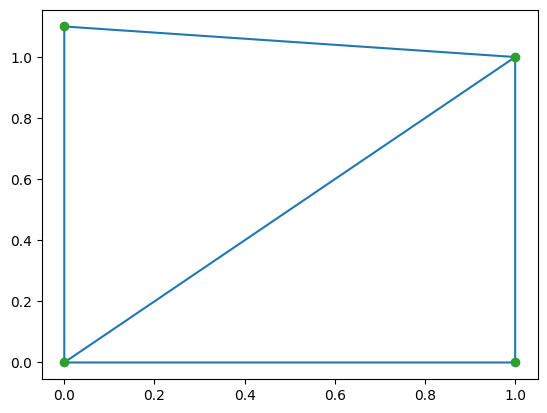

In [37]:
import matplotlib.pyplot as plt
plt.triplot(points[:,0], points[:,1], tri.simplices)
plt.plot(points[:,0], points[:,1], 'o')
plt.show()

Ecrire une fonction qui à partir d'un ensemble de points extraits d'une image contruit la triangulation de Delaunay de cet ensemble de points 

In [38]:
def get_delaunay (image):
    """
    Computes the Delaunay triangulation of points in the image.
    
    Args:
        image: Input image
    
    Returns:
        Delaunay triangulation object and points array
    """
    h, w = image.shape[:2]
    
    # Select interest points
    points = select_interest_points(image, 150)
    
    # Create list for corners if needed
    points_list = list(points)
    points_list.append([0, 0])
    points_list.append([w-1, 0])
    points_list.append([0, h-1])
    points_list.append([w-1, h-1])
    
    points_array = np.array(points_list, dtype=np.float32)
    
    # Compute Delaunay triangulation
    from scipy.spatial import Delaunay
    tri = Delaunay(points_array)
    
    return tri, points_array

### 2.1.5  Remplir les triangles à l'aide des couleurs de l'image originale

Ici il s'agit d'assigner chaque pixel à un triangle de la triangulation de Delaunay et de faire la moyenne des couleurs dans ce triangle pour obtenir l'image Low Poly



In [39]:
def get_colour_of_tri(tri, image, points):
    """
    Assigns each pixel to a triangle and computes the average color for each triangle.
    
    Args:
        tri: Delaunay triangulation object
        image: Input image
        points: Array of points used in triangulation
    
    Returns:
        Dictionary mapping triangle indices to average colors
    """
    h, w = image.shape[:2]
    
    # Convert image to float for color calculations
    if len(image.shape) == 3:
        img_float = image.astype(np.float32)
    else:
        img_float = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR).astype(np.float32)
    
    triangle_colors = {}
    
    # For each triangle
    for simplex_idx, simplex in enumerate(tri.simplices):
        # Get the three vertices of the triangle
        p1, p2, p3 = points[simplex]
        
        # Find simplex for all pixels
        simplex_indices = tri.find_simplex(np.array([[x, y] for y in range(h) for x in range(w)]))
        
        # Find pixels belonging to this triangle
        pixel_mask = simplex_indices == simplex_idx
        
        if np.any(pixel_mask):
            pixels = np.array([[x, y] for y in range(h) for x in range(w)])[pixel_mask]
            
            # Get colors of pixels in this triangle
            colors = img_float[pixels[:, 1], pixels[:, 0]]
            
            # Compute average color
            avg_color = np.mean(colors, axis=0)
            triangle_colors[simplex_idx] = avg_color
    
    return triangle_colors

Ecrire la fonction permettant de générer l'image Low Poly. Il s'agit donc de tracer les triangles et de donner la couleur moyenne des pixels à l'intérieur de chaque triangle. Les fonctions [`cv2.line`](https://docs.opencv.org/4.x/d6/d6e/group__imgproc__draw.html) et [`find_simplex`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.Delaunay.find_simplex.html) pourraient vous être utiles.

In [40]:
def generate_low_poly_img (img):
    """
    Generates a low poly version of the input image.
    
    Args:
        img: Input image
    
    Returns:
        Low poly version of the image
    """
    h, w = img.shape[:2]
    
    # Get Delaunay triangulation
    tri, points = get_delaunay(img)
    
    # Get average colors for each triangle
    triangle_colors = get_colour_of_tri(tri, img, points)
    
    # Create output image
    low_poly_img = np.zeros_like(img, dtype=np.uint8)
    
    # Draw each triangle with its average color
    for simplex_idx, simplex in enumerate(tri.simplices):
        if simplex_idx in triangle_colors:
            # Get triangle vertices
            p1 = points[simplex[0]].astype(np.int32)
            p2 = points[simplex[1]].astype(np.int32)
            p3 = points[simplex[2]].astype(np.int32)
            
            # Create triangle points array
            triangle_pts = np.array([p1, p2, p3], dtype=np.int32)
            
            # Get the average color for this triangle
            avg_color = triangle_colors[simplex_idx]
            if len(img.shape) == 3:
                color = tuple(int(c) for c in avg_color)
            else:
                color = (int(avg_color[0]),) * 3
            
            # Fill the triangle
            cv2.fillPoly(low_poly_img, [triangle_pts], color)
            
            # Draw triangle edges
            cv2.polylines(low_poly_img, [triangle_pts], True, (0, 0, 0), 1)
    
    return low_poly_img

Tester vos différentes approches sur les images du répertoire [lowpoly](./lowpoly) et afficher les images originales et les images obtenues.


Processing: campusCS.jpeg
Generating low poly version...


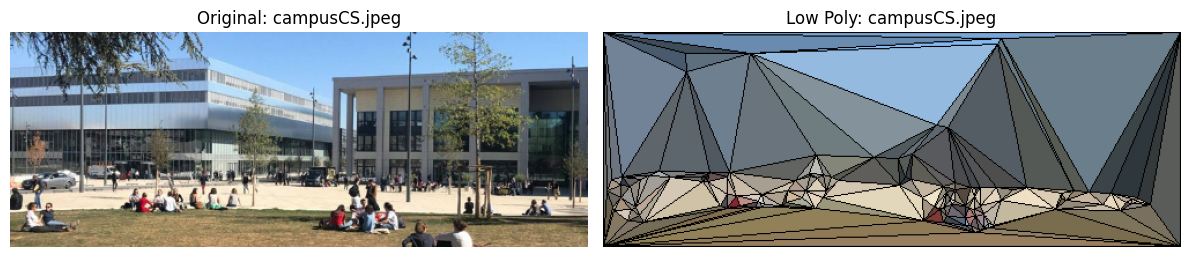

Saved low poly image to: ./lowpoly/results\lowpoly_campusCS.jpeg

Processing: oscar.jpg
Generating low poly version...


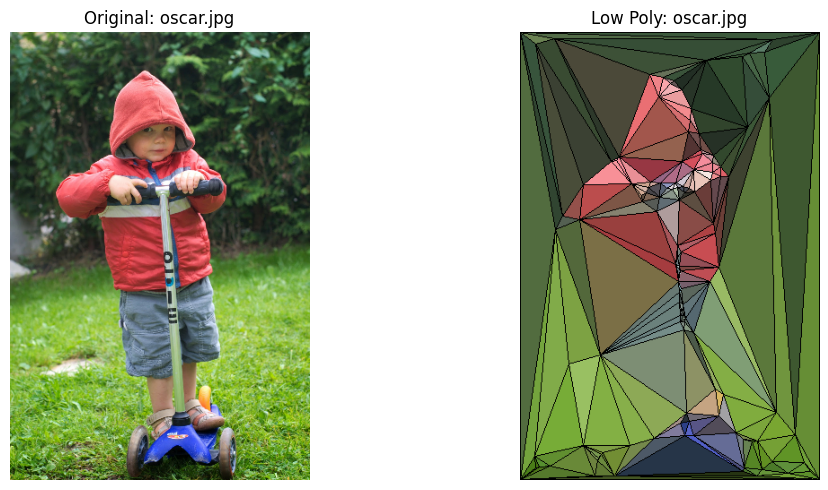

Saved low poly image to: ./lowpoly/results\lowpoly_oscar.jpg


In [ ]:
import os
from pathlib import Path

lowpoly_dir = './lowpoly'
if os.path.exists(lowpoly_dir):
    image_files = [f for f in os.listdir(lowpoly_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    for img_name in image_files[:2]:
        img_path = os.path.join(lowpoly_dir, img_name)
        print(f"\nProcessing: {img_name}")
        
        # Read image
        img = cv2.imread(img_path)
        if img is None:
            print(f"Could not read {img_path}")
            continue
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        if img.shape[0] > 500 or img.shape[1] > 500:
            scale = min(500/img.shape[0], 500/img.shape[1])
            new_size = (int(img.shape[1]*scale), int(img.shape[0]*scale))
            img_rgb = cv2.resize(img_rgb, new_size)
            img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        
        print("Generating low poly version...")
        low_poly = generate_low_poly_img(img)
        low_poly_rgb = cv2.cvtColor(low_poly, cv2.COLOR_BGR2RGB)
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(img_rgb)
        axes[0].set_title(f"Original: {img_name}")
        axes[0].axis('off')
        
        axes[1].imshow(low_poly_rgb)
        axes[1].set_title(f"Low Poly: {img_name}")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        output_dir = './lowpoly/results'
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f"lowpoly_{img_name}")
        cv2.imwrite(output_path, low_poly)
        print(f"Saved low poly image to: {output_path}")
else:
    print(f"Directory {lowpoly_dir} not found")